In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**데이터셋 출처 : kaggle datasets download -d bhavikjikadara/fake-news-detection**

In [5]:
import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/웹텍마 CH1 실습.ipynb
/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/웹텍마 CH6 실습1.ipynb
/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/웹텍마 CH6 실습2.ipynb
/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/웹텍마 CH7 실습1.ipynb
/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/웹텍마 CH7 실습2.ipynb
/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/2172012_김조아_웹과텍스트마이닝개론_중간과제.ipynb
/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/fake news recognition/fake.csv
/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/fake news recognition/true.csv


In [6]:
true_df = pd.read_csv("/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/fake news recognition/true.csv")
true_df

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"
...,...,...,...,...
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"


In [7]:
fake_df = pd.read_csv("/content/drive/MyDrive/2024-1 웹과 텍스트마이닝개론/fake news recognition/fake.csv")
fake_df

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"
...,...,...,...,...
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"


## **1.데이터 분석하기**

### **1-1. 주제별 뉴스 수 분석**

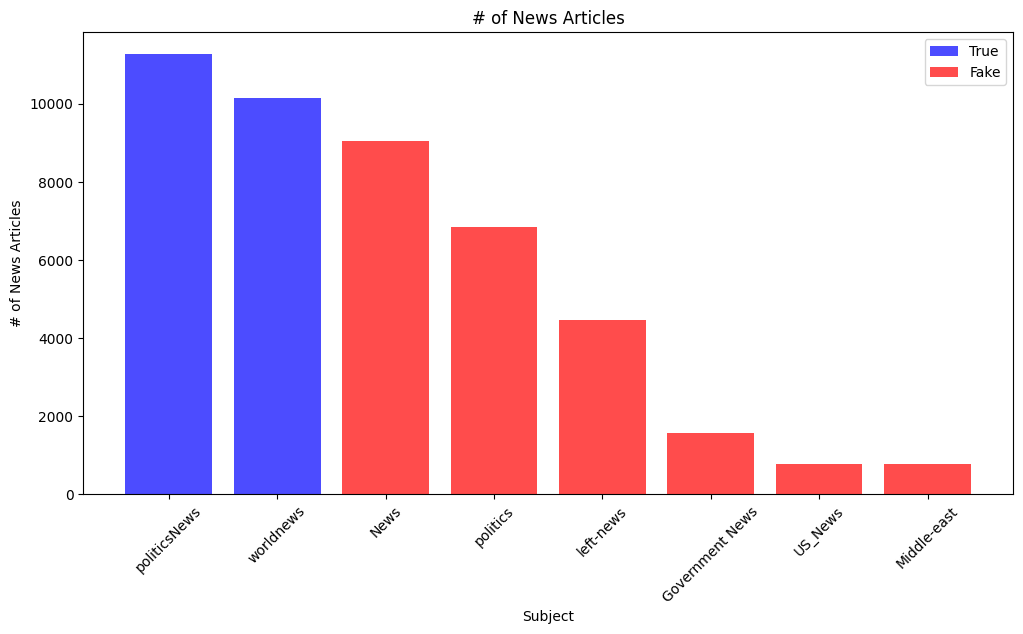

In [ ]:
import matplotlib.pyplot as plt

true_news_count = true_df['subject'].value_counts()
fake_news_count = fake_df['subject'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(true_news_count.index, true_news_count.values, color='blue', alpha=0.7, label='True')
plt.bar(fake_news_count.index, fake_news_count.values, color='red', alpha=0.7, label='Fake')

plt.title('# of News Articles')
plt.xlabel('Subject')
plt.ylabel('# of News Articles')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### **1-2. 시간별 뉴스 수 분석**

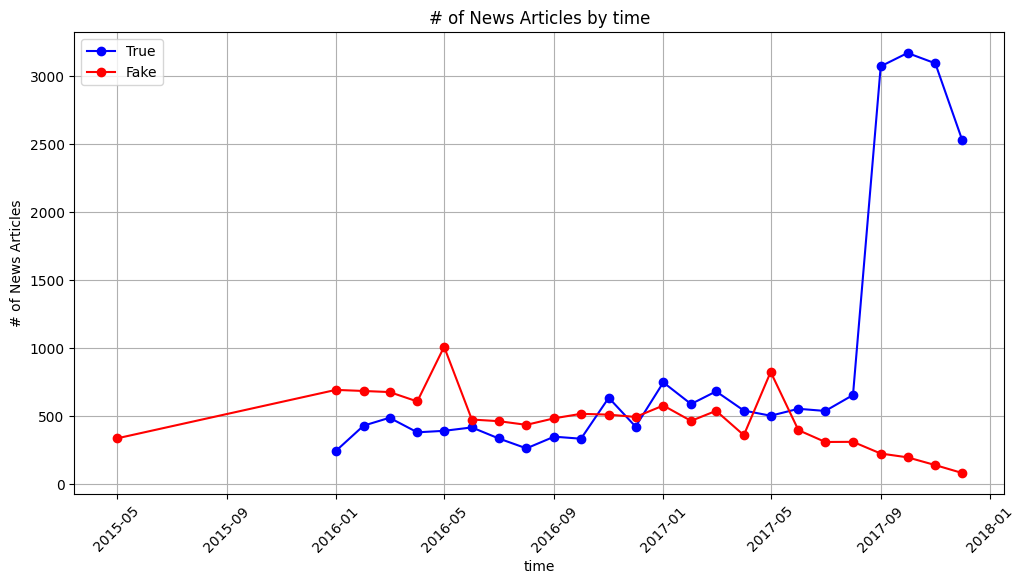

In [ ]:
true_df['date'] = pd.to_datetime(true_df['date'], errors='coerce')
fake_df['date'] = pd.to_datetime(fake_df['date'], errors='coerce')

true_news_count_t = true_df['date'].dt.to_period('M').value_counts().sort_index()
fake_news_count_t = fake_df['date'].dt.to_period('M').value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(true_news_count_t.index.to_timestamp(), true_news_count_t.values, marker='o', color='blue', label='True')
plt.plot(fake_news_count_t.index.to_timestamp(), fake_news_count_t.values, marker='o', color='red', label='Fake')

plt.title('# of News Articles by time')
plt.xlabel('time')
plt.ylabel('# of News Articles')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

### **1-3. 가장 많이 등장하는 단어 분석**

##### **1) WordCloud로 시각화**

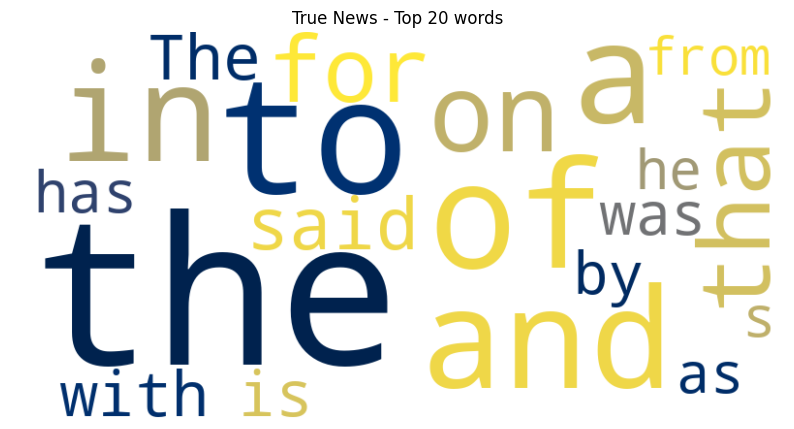

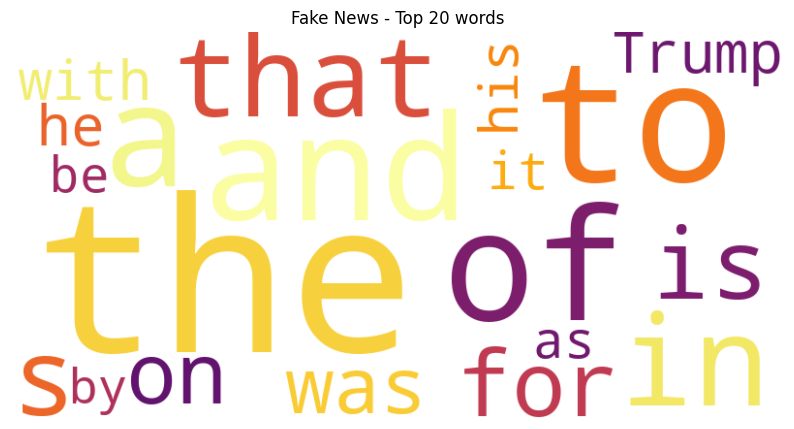

In [ ]:
from collections import Counter
from wordcloud import WordCloud

true_text = ' '.join(true_df['text'].values)
fake_text = ' '.join(fake_df['text'].values)

true_word_counts = Counter(true_text.split())
fake_word_counts = Counter(fake_text.split())
top_true_words = dict(true_word_counts.most_common(20))
top_fake_words = dict(fake_word_counts.most_common(20))

wordcloud = WordCloud(width=800, height=400, background_color='white',colormap='cividis').generate_from_frequencies(top_true_words)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('True News - Top 20 words')
plt.axis('off')
plt.show()

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate_from_frequencies(top_fake_words)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Fake News - Top 20 words')
plt.axis('off')
plt.show()

**the of and .... -> 무의미한 단어이므로 이러한 stopwords를 제거하고 코드를 다시 돌려보자!**

##### **2) WordCloud로 시각화 -> stoprwords 제거**

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


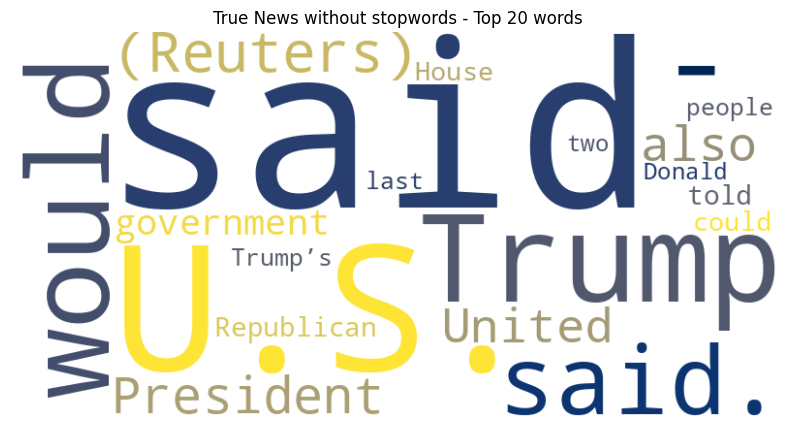

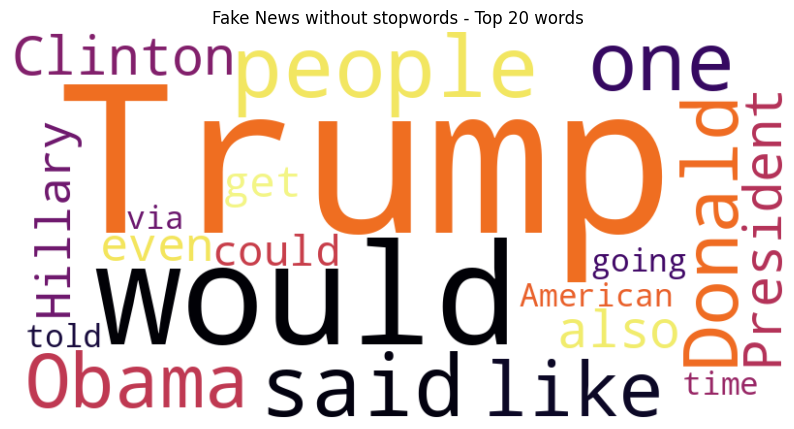

In [ ]:
import nltk
from nltk.corpus import stopwords

# NLTK의 불용어 다운로드
nltk.download('stopwords')

# 영어 불용어 목록 로드
stop_words = set(stopwords.words('english'))

# 불용어 제거
true_text_out = ' '.join(word for word in true_text.split() if word.lower() not in stop_words)
fake_text_out = ' '.join(word for word in fake_text.split() if word.lower() not in stop_words)

true_word_counts_out = Counter(true_text_out.split())
fake_word_counts_out = Counter(fake_text_out.split())
top_true_words_out = dict(true_word_counts_out.most_common(20))
top_fake_words_out = dict(fake_word_counts_out.most_common(20))

wordcloud = WordCloud(width=800, height=400, background_color='white',colormap='cividis').generate_from_frequencies(top_true_words_out)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('True News without stopwords - Top 20 words')
plt.axis('off')
plt.show()

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='inferno').generate_from_frequencies(top_fake_words_out)
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Fake News without stopwords - Top 20 words')
plt.axis('off')
plt.show()

##### **3) 원그래프로 시각화**

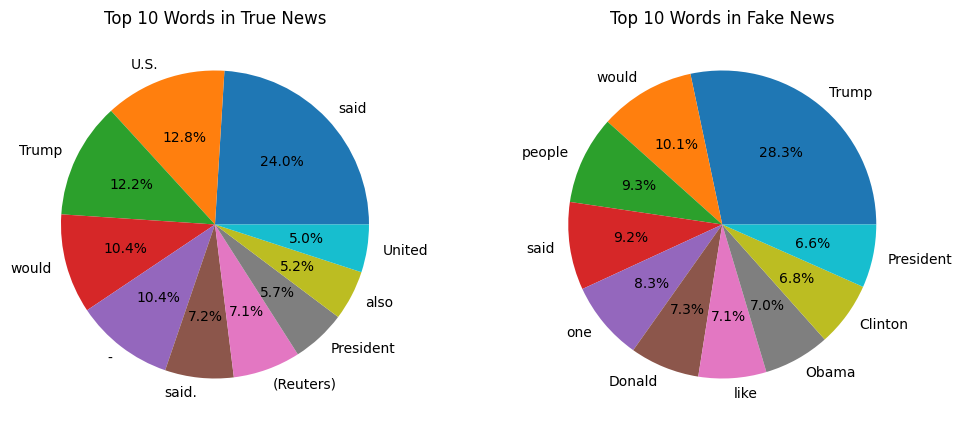

In [ ]:
top_true_words_out = dict(true_word_counts_out.most_common(10))
top_fake_words_out = dict(fake_word_counts_out.most_common(10))

# True 뉴스 원 그래프
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.pie(top_true_words_out.values(), labels=top_true_words_out.keys(), autopct='%1.1f%%')
plt.title('Top 10 Words in True News')

# Fake 뉴스 원 그래프
plt.subplot(1, 2, 2)
plt.pie(top_fake_words_out.values(), labels=top_fake_words_out.keys(), autopct='%1.1f%%')
plt.title('Top 10 Words in Fake News')

plt.show()

##### **4) 표로 빈도수 확인**

In [ ]:
import pandas as pd

top_true_words_out = dict(true_word_counts_out.most_common(30))
top_fake_words_out = dict(fake_word_counts_out.most_common(30))

# True 뉴스 상위 30개 단어 표
df_true = pd.DataFrame(top_true_words_out.items(), columns=['Word', 'Frequency'])

# Fake 뉴스 상위 30개 단어 표
df_fake = pd.DataFrame(top_fake_words_out.items(), columns=['Word', 'Frequency'])

print("Top 30 Words in True News:")
print(df_true)
print("\nTop 30 Words in Fake News:")
print(df_fake)

Top 30 Words in True News:
            Word  Frequency
0           said      72025
1           U.S.      38271
2          Trump      36461
3          would      31330
4              -      31059
5          said.      21582
6      (Reuters)      21239
7      President      17112
8           also      15703
9         United      15030
10    government      14667
11    Republican      14487
12          told      14218
13         House      13622
14         could      13578
15        people      11702
16       Trump’s      11582
17          last      11567
18           two      10310
19        Donald      10263
20           one      10259
21        former       9904
22           new       9308
23         state       9057
24         North       9035
25        States       8687
26         White       8472
27     including       8069
28       percent       7969
29  presidential       7850

Top 30 Words in Fake News:
          Word  Frequency
0        Trump      64844
1        would      23024

## **2. 데이터 합치기**

In [8]:
true_df['Label'] = 'true'
fake_df['Label'] = 'fake'
combined_df=pd.concat([true_df,fake_df])
combined_df=combined_df.reset_index(drop=True)
combined_df

,title,text,subject,date,Label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",true
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",true
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",true
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",true
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",true
...,...,...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",fake
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",fake
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",fake
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",fake


In [7]:
combined_df["subject"].value_counts()

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

## **3. Word2Vec를 사용한 Semantic Network 분석**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

import gensim

from gensim.models import Word2Vec
from gensim.models import KeyedVectors



import urllib.request
from lxml import etree
import xml.etree.ElementTree as elemTree


import re

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize

nltk.download('punkt')   # NLTK sent_tokenize 를 사용하기 위해서 필요한 화일임


import time
import datetime


import warnings
warnings.filterwarnings('ignore')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
!pip show gensim

Name: gensim
Version: 4.3.2
Summary: Python framework for fast Vector Space Modelling
Home-page: https://radimrehurek.com/gensim/
Author: Radim Rehurek
Author-email: me@radimrehurek.com
License: LGPL-2.1-only
Location: /usr/local/lib/python3.10/dist-packages
Requires: numpy, scipy, smart-open
Required-by: 


In [9]:
model = Word2Vec(sentences=[word_tokenize(text) for text in combined_df['text']], vector_size=100, window=5, min_count=5, workers=4, sg=0)

In [10]:
# wv 함수를 이용하여 단어의 벡터 값 확인
vector_value = model.wv["President"]
print(vector_value)

# most_similar 함수를 이용하여 유사단어 찾기
model_result = model.wv.most_similar("President")
print(model_result)

# 생성된 Word2Vec 모델 저장하고 재사용하기 (방법 1)
model.wv.save_word2vec_format('word2vec_model.bin')

# KeyedVectors 함수를 이용하여 훈련된 모델을 리로드
loaded_model = KeyedVectors.load_word2vec_format("word2vec_model.bin")

# load 한 모델 확인하기
model_result = loaded_model.most_similar("President")
print(model_result)

# 최종 모델 저장 방법 2
model.save('word2vec.model')

[ 4.280335    1.7345786  -2.8094776  -1.4040394   4.4435477  -3.6694624
  3.3489647  -2.9163282  -0.69249916  0.08440109 -1.2692943   1.5488516
  0.22663964 -5.3065276  -0.81404227 -3.1390235   1.7931696   2.8057048
 -0.16240798  1.0034454  -0.6562745  -3.4219356   1.5217038  -2.329033
  0.91189027 -4.1493654  -1.9169457   0.13190728  3.792869    0.21584369
 -4.8091235  -1.7738074  -1.9011451   1.236047   -2.1858106  -0.97487915
  5.123363   -1.5432059   1.6825986   0.08954544  1.4206461   0.65441614
  1.6952304   1.8916289   2.3143682   0.5003786  -1.0992239  -0.02831682
  2.424958    0.7514802   1.5221446  -0.69152915  2.636942   -2.4071333
  0.03835132  1.1796467  -0.19302444  1.543283    2.6461406   3.6958191
  0.6020284   1.5440742  -1.2381306   2.4735048  -2.8598244  -2.5962267
 -0.923323    0.936476   -0.8323471  -1.6519779  -1.5115696   2.1259077
  1.1504371   1.9907335   0.48299965 -3.4645224  -5.350029   -0.90764123
 -1.4504765  -1.3100432   1.1951733  -3.6584415   0.93349755

In [ ]:
loaded_model2 = Word2Vec.load('word2vec.model')

model_result = loaded_model2.wv.most_similar("Trump")

print(model_result)

[('Obama', 0.6480299830436707), ('he', 0.6341026425361633), ('Cruz', 0.6027784943580627), ('president-elect', 0.5901556611061096), ('him', 0.5828008055686951), ('Duterte', 0.5778465270996094), ('Rubio', 0.565692663192749), ('Tillerson', 0.5600401759147644), ('trump', 0.5587292313575745), ('Macron', 0.5550072193145752)]


In [ ]:
loaded_model2 = Word2Vec.load('word2vec.model')

model_result = loaded_model2.wv.most_similar("American")

print(model_result)

[('America', 0.5833708047866821), ('U.S.', 0.5768527984619141), ('US', 0.5569223165512085), ('ordinary', 0.5566798448562622), ('Chinese', 0.5035198926925659), ('law-abiding', 0.4967747926712036), ('Cuban', 0.4935300946235657), ('Korean', 0.48547717928886414), ('American-style', 0.46222761273384094), ('Asian', 0.45803821086883545)]
